# `n_reads` and exposure-time-for-SNR inverses

This notebook demonstrates two related `wcc_etc.Simulation` capabilities:

- **`n_reads`** — the number of detector reads (frames) that span the *total* exposure `t`,
  so each frame integrates `t / n_reads`. This models CDS / Fowler-style multiple sampling:
  coadding more reads reduces the effective read-noise penalty per unit time, pushing the SNR
  toward the photon-limited ceiling. Because the read is **per frame**, splitting a fixed total
  time across more reads also lowers the per-frame peak charge — which can keep a bright star
  under full-well and flip `is_saturated` from `True` to `False`.

- **Exposure-time inverses** — `get_exptime_for_snr(snr)` (analytic) and
  `get_image_exptime_for_snr(snr, ...)` (PSF-aware) answer *how long* to integrate to reach a
  target SNR. They invert `get_snr` / `get_image_snr`, and we verify the round trip below.

`n_reads` is a settable `Simulation` parameter (default 1, validated `>= 1`), updatable via
`sim.update(n_reads=N)` or passable per call as `n_reads=`.

## Setup

Import the package, build a G5V source scene over a zodiacal background, and construct a
`Simulation` from the Sony `r` sensor+filter combination.

In [1]:
import warnings
warnings.simplefilter('ignore')  # silence harmless DEPRECATION UserWarning

import numpy as np
import matplotlib.pyplot as plt

import wcc_etc
wcc_etc.set_wcc_style()

scene = wcc_etc.get_scene(name='G5V', mag=15, background='zodi', bandpass='johnson_r',
                          background_prop={'bandpass': 'johnson_r', 'mag': 22.5})
sim = wcc_etc.Simulation.from_sensor_and_scene('sony:r', scene)
print('wcc_etc loaded; sim built. default n_reads =', sim.meta.get('n_reads', 1))

wcc_etc loaded; sim built. default n_reads = 1


## 1. Analytic round-trip

Pick a target SNR, compute the required time with `get_exptime_for_snr`, then feed it back into
`get_snr` and confirm we recover the target (within ~1%).

In [2]:
snr_target = 100.0
t = sim.get_exptime_for_snr(snr_target)            # Quantity in seconds
snr_back = float(sim.get_snr(t).value)

print(f'target SNR        = {snr_target:.2f}')
print(f'exptime for SNR   = {t.value:.3f} s')
print(f'get_snr(t)        = {snr_back:.4f}')

rel_err = abs(snr_back - snr_target) / snr_target
print(f'relative error    = {rel_err:.2e}')
assert rel_err < 0.01, 'analytic round-trip disagreement'
print('analytic round-trip OK (<1%)')

target SNR        = 100.00
exptime for SNR   = 0.324 s
get_snr(t)        = 100.0000
relative error    = 1.42e-16
analytic round-trip OK (<1%)


## 2. PSF-aware round-trip

The PSF-aware path renders the PSF and solves per aperture. `get_image_exptime_for_snr` returns
a dict; we feed `res['time_s']` back into `get_image_snr` and confirm the recovered SNR.

In [3]:
res = sim.get_image_exptime_for_snr(snr_target)
snr_img_back = sim.get_image_snr(time=res['time_s'])['snr']

print(f"target SNR          = {snr_target:.2f}")
print(f"exptime for SNR     = {res['time_s']:.3f} s")
print(f"aperture radius     = {res['r_aper_mas']:.1f} mas")
print(f"enclosed fraction   = {res['enclosed_fraction']:.4f}")
print(f"n_pix               = {res['n_pix']}")
print(f"get_image_snr(t)    = {snr_img_back:.4f}")

rel_err_img = abs(snr_img_back - snr_target) / snr_target
print(f'relative error      = {rel_err_img:.2e}')
assert rel_err_img < 0.01, 'PSF-aware round-trip disagreement'
print('PSF-aware round-trip OK (<1%)')

target SNR          = 100.00
exptime for SNR     = 0.329 s
aperture radius     = 64.2 mas
enclosed fraction   = 0.8856
n_pix               = 52
get_image_snr(t)    = 100.0000
relative error      = 0.00e+00
PSF-aware round-trip OK (<1%)


## 3. SNR vs `n_reads` at fixed exposure time

At a fixed *total* exposure time, more reads incur the read noise more times. In the
read-noise-affected regime SNR falls slightly with `n_reads`; in the photon-limited regime the
curve flattens toward the photon ceiling. We use a fainter source so the read-noise term is
visible, and overlay the `n_reads=1` (photon-limit-approaching) value as the ceiling reference.

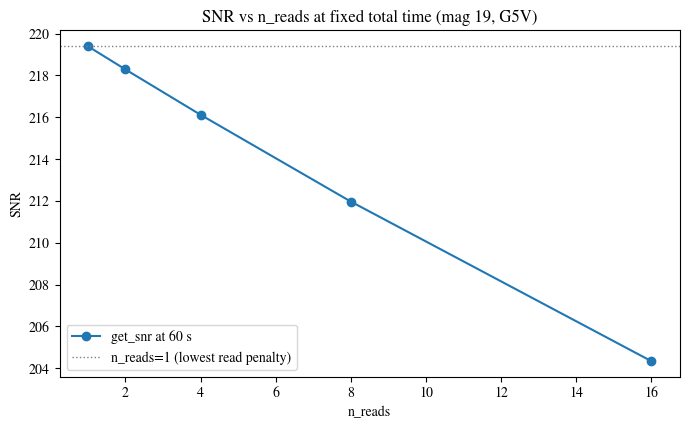

n_reads=  1:  SNR(60 s) = 219.397
n_reads=  2:  SNR(60 s) = 218.288
n_reads=  4:  SNR(60 s) = 216.119
n_reads=  8:  SNR(60 s) = 211.969
n_reads= 16:  SNR(60 s) = 204.339


In [4]:
scene_faint = wcc_etc.get_scene(name='G5V', mag=19, background='zodi', bandpass='johnson_r',
                                background_prop={'bandpass': 'johnson_r', 'mag': 22.5})
sim_faint = wcc_etc.Simulation.from_sensor_and_scene('sony:r', scene_faint)

fixed_t = 60.0
reads = [1, 2, 4, 8, 16]
snr_vs_reads = []
for N in reads:
    sim_faint.update(n_reads=N)
    snr_vs_reads.append(float(sim_faint.get_snr(fixed_t).value))

ceiling = snr_vs_reads[0]  # n_reads=1 -> least read-noise penalty
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(reads, snr_vs_reads, 'o-', label=f'get_snr at {fixed_t:.0f} s')
ax.axhline(ceiling, color='grey', ls=':', lw=1, label='n_reads=1 (lowest read penalty)')
ax.set_xlabel('n_reads'); ax.set_ylabel('SNR')
ax.set_title('SNR vs n_reads at fixed total time (mag 19, G5V)')
ax.legend()
plt.show()

for N, s in zip(reads, snr_vs_reads):
    print(f'n_reads={N:>3}:  SNR({fixed_t:.0f} s) = {s:.3f}')

## 4. Required time for a fixed SNR vs `n_reads`

For a fixed target SNR, the required exposure time grows with `n_reads` because the read-noise
variance is paid once per frame. Conversely, fewer reads minimize the read-noise penalty and the
required time. Plotted on the same fainter source.

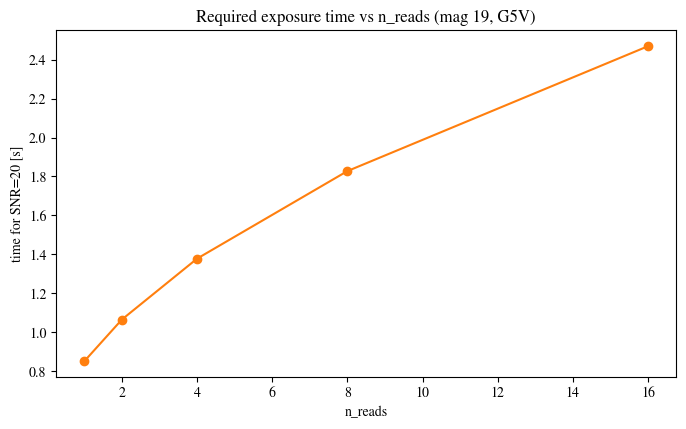

n_reads=  1:  t(SNR=20) =    0.851 s
n_reads=  2:  t(SNR=20) =    1.066 s
n_reads=  4:  t(SNR=20) =    1.378 s
n_reads=  8:  t(SNR=20) =    1.828 s
n_reads= 16:  t(SNR=20) =    2.469 s


In [5]:
snr_goal = 20.0
t_vs_reads = []
for N in reads:
    sim_faint.update(n_reads=N)
    t_vs_reads.append(sim_faint.get_exptime_for_snr(snr_goal).value)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(reads, t_vs_reads, 'o-', color='C1')
ax.set_xlabel('n_reads'); ax.set_ylabel(f'time for SNR={snr_goal:.0f} [s]')
ax.set_title('Required exposure time vs n_reads (mag 19, G5V)')
plt.show()

for N, tt in zip(reads, t_vs_reads):
    print(f'n_reads={N:>3}:  t(SNR={snr_goal:.0f}) = {tt:8.3f} s')

## 5. Per-frame saturation flip

Saturation is evaluated on a single `t / n_reads` frame. A bright source that saturates in one
long frame (`n_reads=1`) can be brought back under the ADC full scale by spreading the same total
time across more reads — the per-frame peak charge scales as `1 / n_reads`.

In [6]:
scene_bright = wcc_etc.get_scene(name='G5V', mag=17, background='zodi', bandpass='johnson_r',
                                 background_prop={'bandpass': 'johnson_r', 'mag': 22.5})
sim_bright = wcc_etc.Simulation.from_sensor_and_scene('sony:r', scene_bright)

total_t = 60.0
adc_max = sim_bright.sensor.adc_max
adc_max_val = float(adc_max.value if hasattr(adc_max, 'value') else adc_max)
print(f'adc_max (full scale) = {adc_max_val:.0f} ADU\n')

sat_reads = [1, 2, 5, 10, 25, 50]
flip_at = None
print(f"{'n_reads':>8} {'peak [ADU]':>12} {'saturated':>10}")
for N in sat_reads:
    sim_bright.update(n_reads=N)
    peak = sim_bright.get_peak_pixel(total_t, units='adu').value
    sat = bool(sim_bright.is_saturated(total_t))
    if flip_at is None and not sat:
        flip_at = N
    print(f'{N:>8} {peak:>12.0f} {str(sat):>10}')

print(f'\nsaturation flips True -> False at n_reads = {flip_at}  '
      f'(total time {total_t:.0f} s, mag 17 G5V)')
assert flip_at is not None, 'expected a saturation flip across the n_reads range'

adc_max (full scale) = 65535 ADU

 n_reads   peak [ADU]  saturated


       1       147072       True
       2        73536       True
       5        29414      False
      10        14707      False
      25         5883      False
      50         2941      False

saturation flips True -> False at n_reads = 5  (total time 60 s, mag 17 G5V)


## Summary

- `get_exptime_for_snr` (analytic) and `get_image_exptime_for_snr` (PSF-aware) invert the SNR
  calculation; both round-trip back through `get_snr` / `get_image_snr` to the target within ~1%.
- `n_reads` coadds frames over the total exposure: at fixed time, more reads add the read-noise
  penalty more times (SNR drops toward / sits at the photon ceiling); for a fixed target SNR the
  required time grows with `n_reads`.
- Saturation is **per frame** (`t / n_reads`): increasing `n_reads` lowers the per-frame peak
  (∝ 1/n_reads) and can flip `is_saturated` from `True` to `False`.
- `n_reads=1` reproduces the original single-frame behaviour.